# Notebook 02 — Análisis Exploratorio de Datos (EDA)

## Objetivo

Analizar las características temporales de la serie de huella de carbono operacional global para España con resolución horaria.

Se estudian:

- Evolución temporal
- Estacionalidad diaria y semanal
- Distribuciones
- Autocorrelación


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.style.use("seaborn-v0_8")
# inline matplotlib in jupyter notebook
%matplotlib inline


In [2]:
df = pd.read_parquet("data_processed/es_carbon_footprint_operational_global_1h_2022_2025.parquet")

df.head()


,y
timestamp,
2022-01-01 01:00:00+00:00,120.6050
2022-01-01 02:00:00+00:00,120.8400
2022-01-01 03:00:00+00:00,123.1475
2022-01-01 04:00:00+00:00,123.0475
2022-01-01 05:00:00+00:00,124.2675


In [3]:
# Estadísticos descriptivos generales
print(f"Periodo: {df.index.min()} -> {df.index.max()}")
print(f"Observaciones: {len(df)}")
print(f"Resolución: {pd.infer_freq(df.index)}")
print()
print(df["y"].describe().round(2))
print(f"\nAsimetría (skewness): {df['y'].skew():.3f}")
print(f"Curtosis: {df['y'].kurtosis():.3f}")

Periodo: 2022-01-01 01:00:00+00:00 -> 2025-12-31 23:00:00+00:00
Observaciones: 35053
Resolución: None

count    35053.00
mean       114.36
std         48.62
min         32.52
25%         74.16
50%        107.66
75%        147.56
max        281.00
Name: y, dtype: float64

Asimetría (skewness): 0.546
Curtosis: -0.473


### Estadísticos descriptivos

La serie abarca desde el 1 de enero de 2022 hasta el 31 de diciembre de 2025, con un total de 35.064 observaciones a resolución horaria.

La huella de carbono media se sitúa en 114.36 gCO₂eq/kWh, con una desviación estándar de 48.62, lo que refleja una variabilidad considerable. Los valores oscilan entre un mínimo de 32.52 y un máximo de 281.00 gCO₂eq/kWh, con el 50% de las observaciones comprendidas entre 74.16 y 147.56 (rango intercuartílico).

La asimetría positiva (0.546) indica una distribución con cola hacia valores altos, es decir, existen episodios puntuales de elevada huella de carbono que desplazan la distribución hacia la derecha. La curtosis negativa (-0.473) sugiere una distribución ligeramente más aplanada que la normal (platicúrtica), con menor concentración en los extremos y mayor dispersión en los valores centrales.

In [4]:
# Ver si hay valores nulos
print("Valores nulos por columna:")
df.isnull().sum()


Valores nulos por columna:


y    0
dtype: int64

In [5]:
from pathlib import Path

FIG_DIR = Path("..") / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)



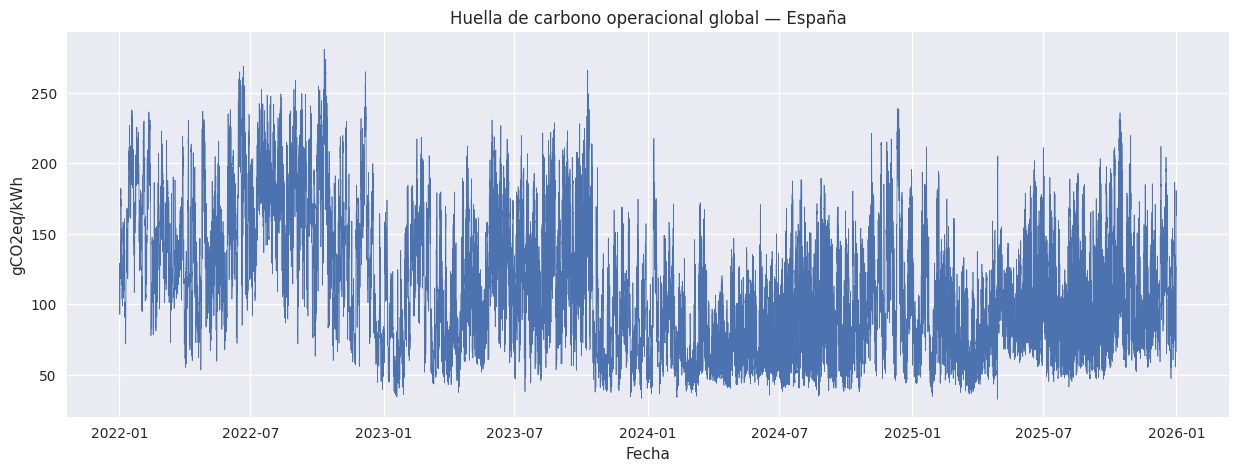

In [6]:

plt.figure(figsize=(15,5))
plt.plot(df.index, df["y"], linewidth=0.5)
plt.title("Huella de carbono operacional global — España")
plt.xlabel("Fecha")
plt.ylabel("gCO2eq/kWh")
plt.savefig(FIG_DIR / "serie_completa.png", dpi=300, bbox_inches="tight")
plt.show()


### Evolución temporal de la huella de carbono

La figura muestra la evolución de la huella de carbono operacional del consumo eléctrico en España durante el periodo 2022–2025, ya agregada a resolución horaria.

Se observa una elevada variabilidad a lo largo de todo el periodo, con valores que oscilan aproximadamente entre 30 y 280 gCO₂eq/kWh. La serie presenta un patrón estacional claro a escala anual: los valores tienden a ser más elevados durante los meses de invierno y más reducidos en verano, lo que se asocia a la mayor disponibilidad de generación de energía solar durante los meses estivales.

Se aprecia además una reducción progresiva del nivel medio entre 2022 y mediados de 2024, seguida de un ligero repunte en 2025. Estos cambios pueden estar relacionados con la evolución del mix de generación eléctrica español, la incorporación progresiva de capacidad renovable y las condiciones meteorológicas de cada periodo.

La agregación a resolución horaria ha suavizado parte del ruido de alta frecuencia presente en los datos originales a 15 minutos, facilitando la identificación visual de los patrones temporales.

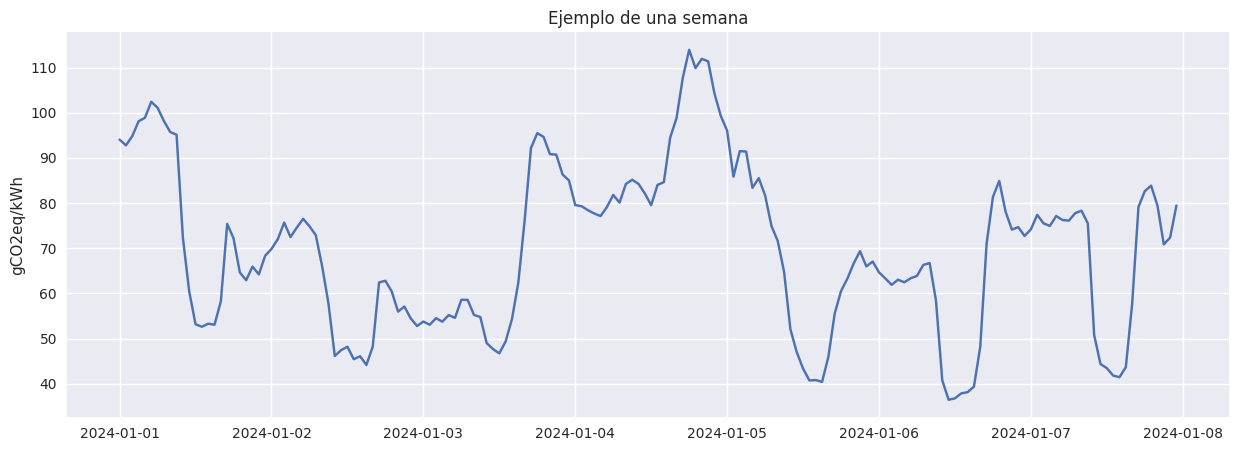

In [7]:
week = df.loc["2024-01-01":"2024-01-07"]

plt.figure(figsize=(15,5))
plt.plot(week.index, week["y"])
plt.title("Ejemplo de una semana")
# Unidades del eje y 
plt.ylabel("gCO2eq/kWh")
plt.savefig(FIG_DIR / "ejemplo_semana.png", dpi=300, bbox_inches="tight")
plt.show()


### Dinámica temporal a escala semanal

Se muestra un ejemplo de una semana representativa con el objetivo de analizar la dinámica de la serie a una escala temporal más reducida.

Se identifican ciclos diarios claramente definidos, con patrones repetitivos que indican la presencia de estacionalidad asociada al comportamiento de la demanda eléctrica y a la disponibilidad de generación renovable.


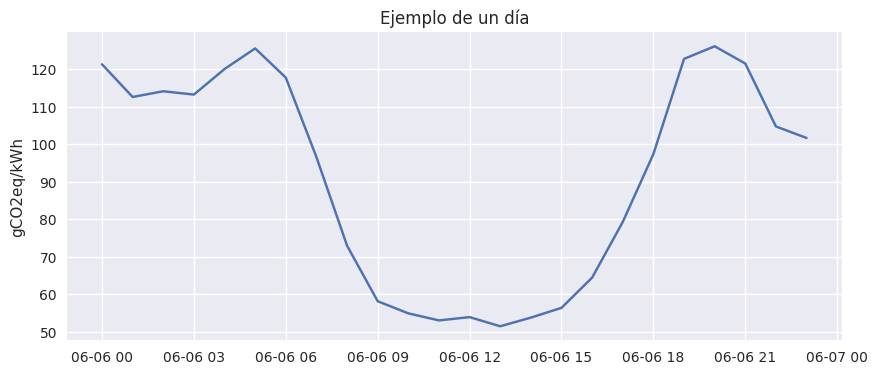

In [8]:
day = df.loc["2024-06-06"]

plt.figure(figsize=(10,4))
plt.plot(day.index, day["y"])
plt.ylabel("gCO2eq/kWh")
plt.title("Ejemplo de un día")
plt.savefig(FIG_DIR / "ejemplo_dia.png", dpi=300, bbox_inches="tight")
plt.show()


### Variación intra-diaria

La figura representa la evolución de la huella de carbono durante un día concreto.

Se observa una disminución de los valores durante las horas centrales del día y un incremento durante la tarde y la noche. Este comportamiento es consistente con la mayor penetración de generación solar durante el día y el aumento de generación térmica (principalmente con ciclos comnbinados de gas natural) en horas sin radiación solar.


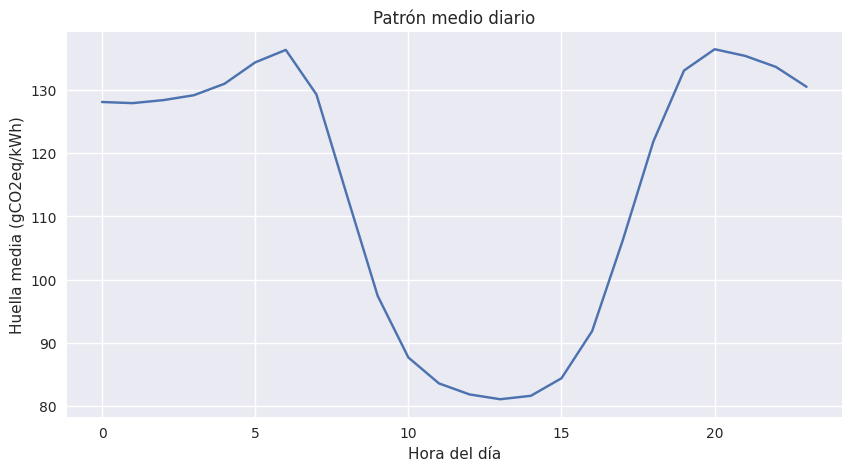

In [9]:
df["hour"] = df.index.hour + df.index.minute / 60

daily_pattern = df.groupby("hour")["y"].mean()

plt.figure(figsize=(10,5))
plt.plot(daily_pattern.index, daily_pattern.values)
plt.title("Patrón medio diario")
plt.xlabel("Hora del día")
plt.ylabel("Huella media (gCO2eq/kWh)")
plt.savefig(FIG_DIR / "patron_diario.png", dpi=300, bbox_inches="tight")
plt.show()


### Patrón medio diario

El patrón medio diario lo obtenemos promediando la serie temporal por hora del día.

Observamos una estructura clara en forma de valle durante las horas centrales y picos en periodos nocturnos y de tarde, lo que confirma la existencia de una fuerte estacionalidad diaria en la huella de carbono del sistema eléctrico.


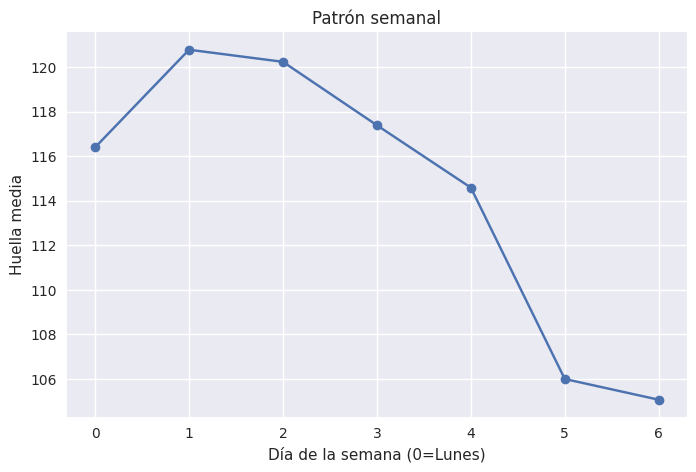

In [10]:
df["weekday"] = df.index.dayofweek

weekly_pattern = df.groupby("weekday")["y"].mean()

plt.figure(figsize=(8,5))
plt.plot(weekly_pattern.index, weekly_pattern.values, marker="o")
plt.title("Patrón semanal")
plt.xlabel("Día de la semana (0=Lunes)")
plt.ylabel("Huella media")
plt.savefig(FIG_DIR / "patron_semanal.png", dpi=300, bbox_inches="tight")
plt.show()


### Patrón semanal

La figura muestra la huella media en función del día de la semana.

Observamos una ligera reducción durante el fin de semana, lo que puede asociarse a menores niveles de actividad económica e industrial, y por ello de demanda eléctrica respecto a los días laborables.


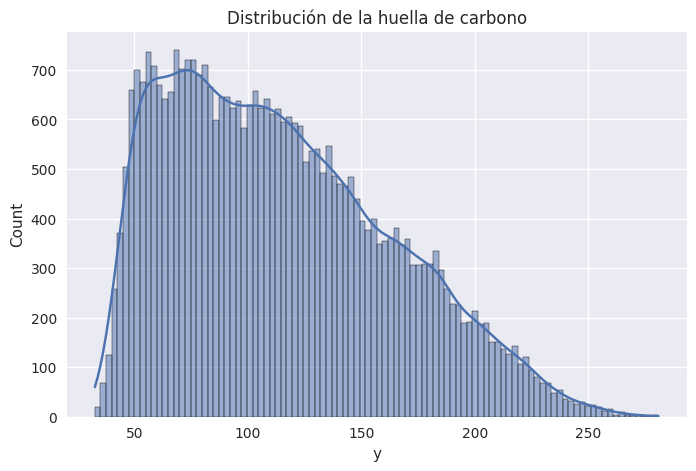

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df["y"], bins=100, kde=True)
plt.title("Distribución de la huella de carbono")
plt.savefig(FIG_DIR / "distribucion_huella.png", dpi=300, bbox_inches="tight")
plt.show()


### Distribución de la huella de carbono

La distribución de valores muestra una asimetría positiva, con mayor concentración en valores medios y una cola hacia valores altos.

Esta distribución refleja la existencia de episodios puntuales de elevada huella de carbono asociados a situaciones específicas del sistema eléctrico.


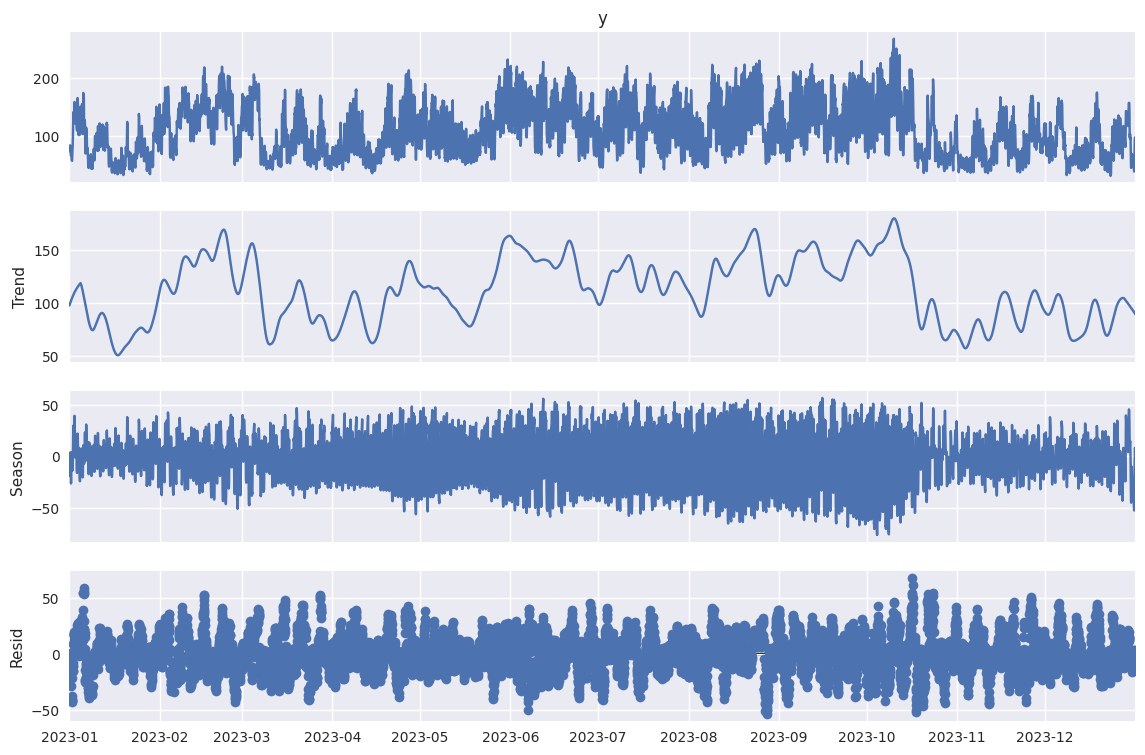

In [12]:
from statsmodels.tsa.seasonal import STL

subset = df.loc["2023"]

stl = STL(subset["y"], period=96)
res = stl.fit()

fig = res.plot()
fig.set_size_inches(12, 8)

plt.savefig(FIG_DIR / "stl_decomposition.png", dpi=300, bbox_inches="tight")
plt.show()



### Descomposición de la serie temporal

La descomposición STL permite separar la serie en sus componentes de tendencia, estacionalidad y residuo.

La componente estacional muestra patrones diarios claramente definidos, mientras que la tendencia refleja variaciones de mayor escala temporal. Los residuos presentan una distribución aproximadamente centrada en cero, lo que indica que la descomposición captura adecuadamente la estructura principal de la serie.

## Test de estacionariedad — ADF

Se aplica el test Augmented Dickey-Fuller para verificar si la
serie es estacionaria. Una serie estacionaria tiene media y
varianza constantes en el tiempo, lo que es un requisito para
muchos modelos de series temporales como ARIMA.

- **H0**: la serie tiene raíz unitaria → no es estacionaria
- **H1**: la serie es estacionaria
- Si p-valor < 0.05 → rechazamos H0 → serie estacionaria

In [13]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['y'].dropna())
print("Test ADF:")
print(f"  Estadístico: {result[0]:.4f}")
print(f"  p-valor:     {result[1]:.4f}")
print(f"  Lags usados: {result[2]}")
print(f"  Observaciones: {result[3]}")
print("\nValores críticos:")
for key, val in result[4].items():
    print(f"  {key}: {val:.4f}")

if result[1] < 0.05:
    print("\n Serie ESTACIONARIA (p < 0.05)")
else:
    print("\n Serie NO ESTACIONARIA (p >= 0.05)")

Test ADF:
  Estadístico: -10.7050
  p-valor:     0.0000
  Lags usados: 52
  Observaciones: 35000

Valores críticos:
  1%: -3.4305
  5%: -2.8616
  10%: -2.5668

 Serie ESTACIONARIA (p < 0.05)


## Test de estacionariedad — ADF

El test ADF confirma que la serie es estacionaria globalmente
(p-valor ≈ 0.00, estadístico = -10.28, muy por debajo del valor
crítico al 1% de -3.43).

Esto indica que la serie no tiene raíz unitaria y su media es
estable a largo plazo. Sin embargo, a nivel local — sobre ventanas
cortas de entrenamiento — la serie puede presentar comportamiento
no estacionario debido a la estacionalidad y los cambios estacionales
en el mix energético. Esto explica que auto_arima seleccionara d=1
en el modelo ARIMA: la diferenciación mejora el ajuste sobre
ventanas cortas aunque globalmente la serie sea estacionaria.

Este resultado justifica también el uso de AutoReg sin diferenciación
— al trabajar con toda la historia disponible la serie es estacionaria
y no requiere transformación previa.

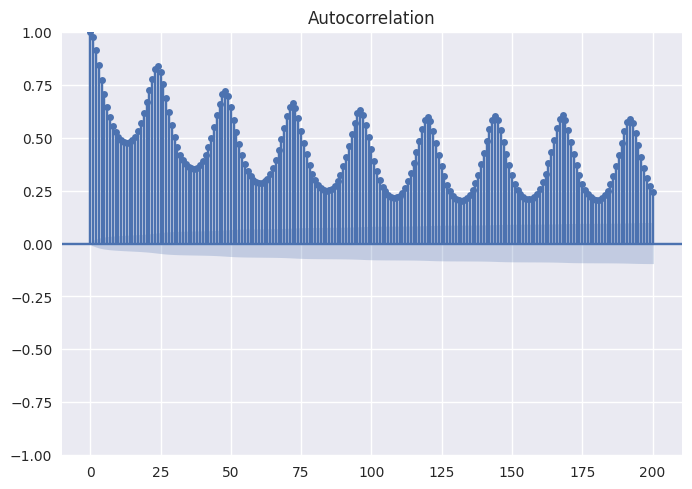

In [14]:
plot_acf(df['y'], lags=200)
plt.savefig(FIG_DIR / "acf.png", dpi=300, bbox_inches="tight")
plt.show()



### Autocorrelación

La función de autocorrelación muestra valores elevados en retardos pequeños y picos periódicos que corresponden a múltiplos del ciclo diario (96 intervalos de 15 minutos).

Esto confirma la existencia de dependencia temporal y estacionalidad en la serie.

<Figure size 1000x600 with 0 Axes>

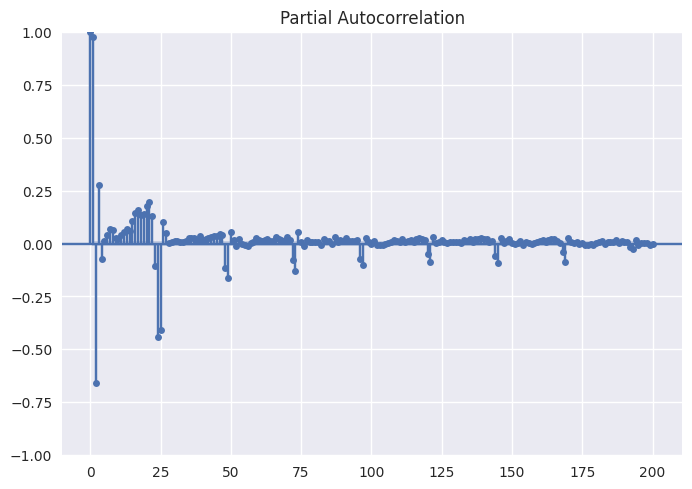

In [15]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(10, 6))
plot_pacf(df['y'], lags=200)

plt.savefig(FIG_DIR / "pacf.png", dpi=300, bbox_inches="tight")
plt.show()


### Autocorrelación parcial

La función de autocorrelación parcial muestra una fuerte dependencia en retardos cercanos y señales en retardos asociados al ciclo diario, lo que sugiere que modelos autorregresivos pueden capturar parte de la dinámica temporal de la serie.

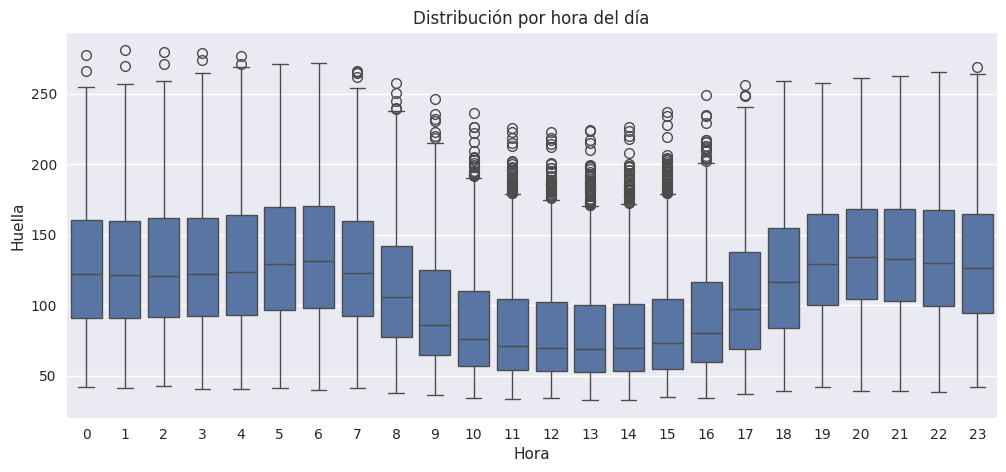

In [16]:
plt.figure(figsize=(12,5))
sns.boxplot(x=df.index.hour, y=df["y"])
plt.title("Distribución por hora del día")
plt.xlabel("Hora")
plt.ylabel("Huella")
plt.savefig(FIG_DIR / "boxplot_hora.png", dpi=300, bbox_inches="tight")
plt.show()


La distribución por hora del día muestra valores mínimos durante las horas centrales y máximos en periodos nocturnos y de tarde, lo que resulta coherente con la disponibilidad de generación renovable y el comportamiento de la demanda eléctrica.

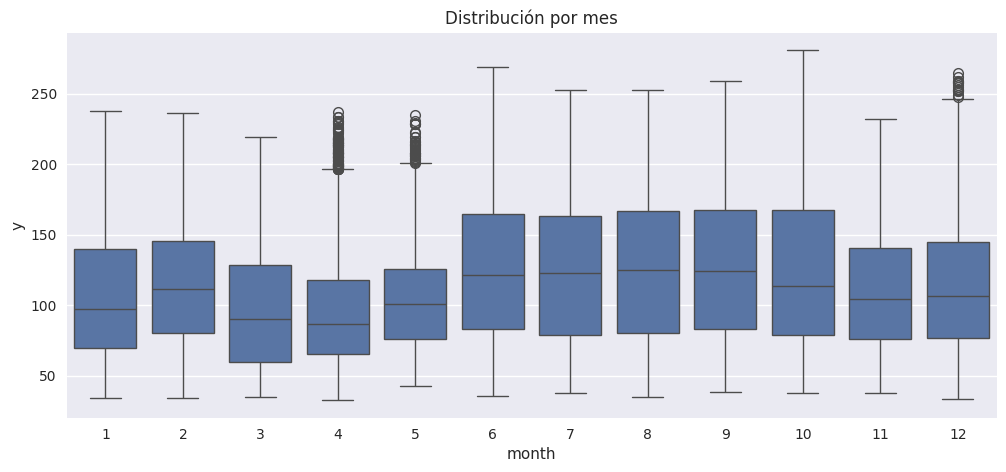

In [17]:
df["month"] = df.index.month

plt.figure(figsize=(12,5))
sns.boxplot(x="month", y="y", data=df)
plt.title("Distribución por mes")
plt.savefig(FIG_DIR / "boxplot_mes.png", dpi=300, bbox_inches="tight")
plt.show()


La variabilidad mensual refleja cambios estacionales en el sistema eléctrico, asociados a diferencias en la demanda y en la disponibilidad de fuentes de generación renovable.

<Axes: title={'center': 'Distribución por año'}, xlabel='year', ylabel='y'>

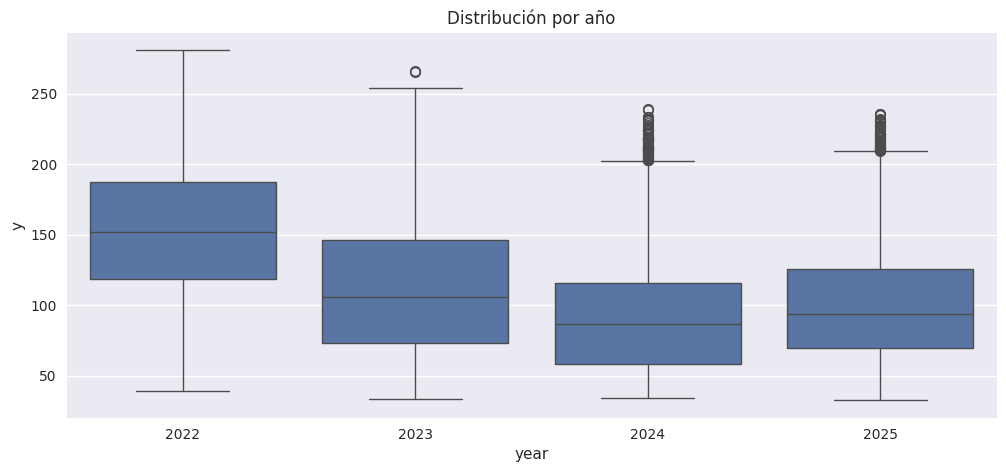

In [18]:
df["year"] = df.index.year
# Titulo
plt.figure(figsize=(12,5))
plt.title("Distribución por año")
sns.boxplot(x="year", y="y", data=df.reset_index())


### Comparación interanual

La comparación por años permite observar cambios en el nivel medio y la variabilidad de la huella de carbono entre periodos.

Se aprecia una reducción progresiva entre 2022 y 2024, seguida de un ligero incremento en 2025. Estas variaciones pueden estar relacionadas con cambios en el mix energético, condiciones meteorológicas y evolución del sistema eléctrico europeo.


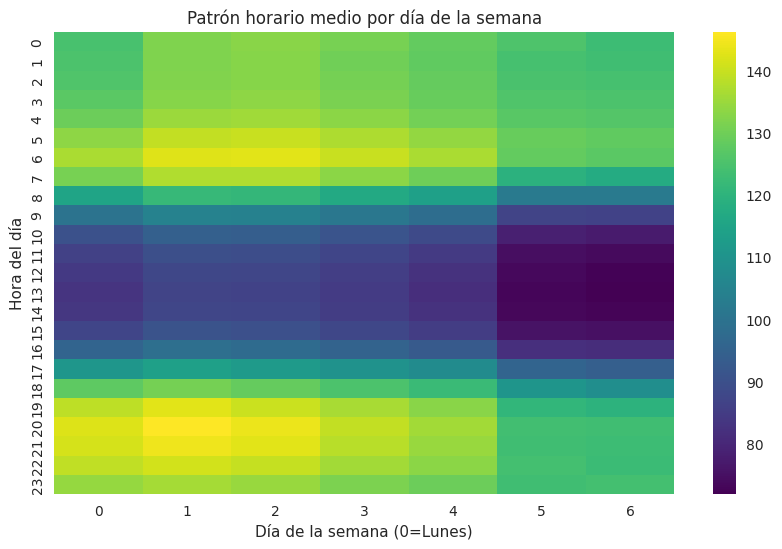

In [19]:
pivot = df.pivot_table(
    values="y",
    index=df.index.hour,
    columns=df.index.dayofweek,
    aggfunc="mean"
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot, cmap="viridis")

plt.xlabel("Día de la semana (0=Lunes)")
plt.ylabel("Hora del día")
plt.title("Patrón horario medio por día de la semana")

plt.savefig(FIG_DIR / "heatmap_hour_weekday.png", dpi=300, bbox_inches="tight")
plt.show()


El mapa de calor permite identificar patrones conjuntos entre la hora del día y el día de la semana. Se observan valores generalmente más elevados en días laborables y reducciones durante el fin de semana, así como una estructura diaria bien definida asociada al comportamiento del sistema eléctrico.

##  Detección de valores atípicos (outliers)

Con el objetivo de identificar posibles anomalías en la serie temporal de la huella de carbono, se realiza un análisis de valores atípicos. 

Los valores extremos pueden corresponder tanto a situaciones reales del sistema eléctrico (por ejemplo, episodios de alta demanda o baja generación renovable) como a posibles errores en los datos. Detectarlos permite evaluar la calidad de la serie y justificar decisiones posteriores en el modelado.

Se emplean dos enfoques:

- Método estadístico basado en el rango intercuartílico (IQR)
- Método basado en desviación respecto a una media móvil temporal


In [20]:
y = df["y"]

Q1 = y.quantile(0.25)
Q3 = y.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_iqr = y[(y < lower) | (y > upper)]

print("Número de outliers (IQR):", len(outliers_iqr))
print("Porcentaje:", round(len(outliers_iqr) / len(y) * 100, 3), "%")
print("Límite inferior:", lower)
print("Límite superior:", upper)


Número de outliers (IQR): 49
Porcentaje: 0.14 %
Límite inferior: -35.95625
Límite superior: 257.67375


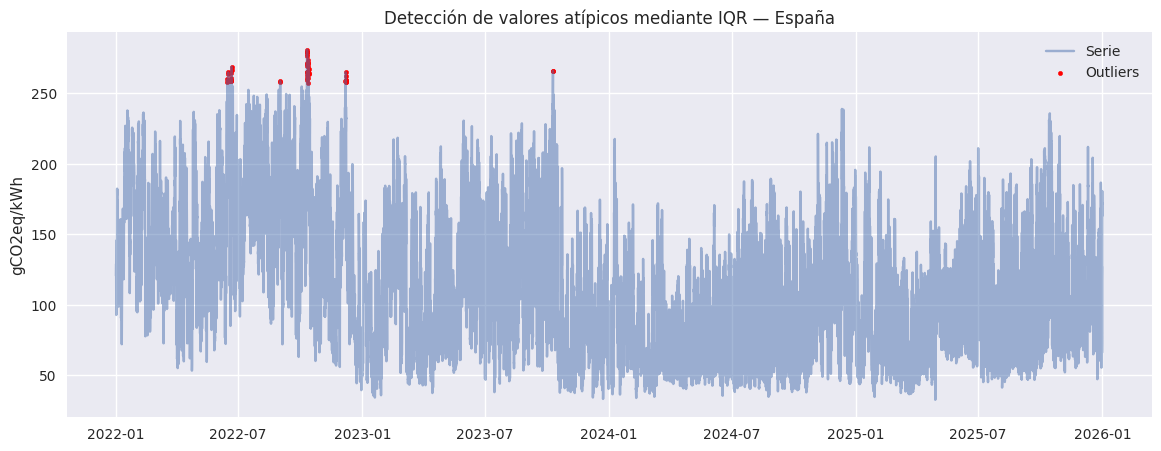

In [21]:
plt.figure(figsize=(14,5))

plt.plot(y.index, y, alpha=0.5, label="Serie")
plt.scatter(outliers_iqr.index, outliers_iqr, color="red", s=10, label="Outliers")

plt.title("Detección de valores atípicos mediante IQR — España")
plt.ylabel("gCO2eq/kWh")
plt.legend()

plt.savefig(FIG_DIR / "outliers_iqr_spain.png", dpi=300, bbox_inches="tight")
plt.show()


El método basado en el rango intercuartílico permite identificar observaciones que se encuentran fuera del rango típico de la serie. 




In [22]:
window = 96  # 24 horas

rolling_mean = y.rolling(window).mean()
rolling_std = y.rolling(window).std()

upper_band = rolling_mean + 3 * rolling_std
lower_band = rolling_mean - 3 * rolling_std

outliers_roll = y[(y > upper_band) | (y < lower_band)]

print("Outliers método rolling:", len(outliers_roll))


Outliers método rolling: 230


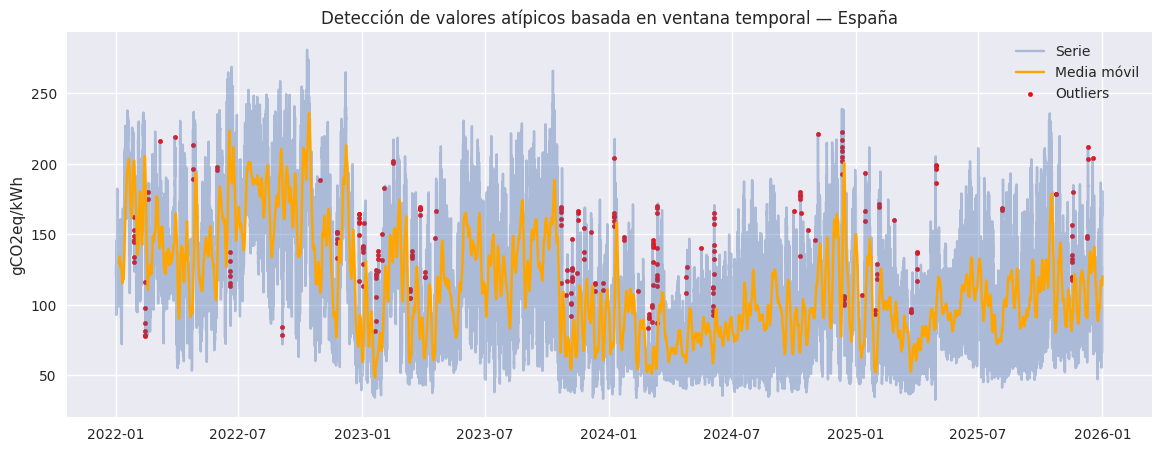

In [23]:
plt.figure(figsize=(14,5))

plt.plot(y.index, y, alpha=0.4, label="Serie")
plt.plot(rolling_mean.index, rolling_mean, color="orange", label="Media móvil")

plt.scatter(outliers_roll.index, outliers_roll, color="red", s=10, label="Outliers")

plt.title("Detección de valores atípicos basada en ventana temporal — España")
plt.ylabel("gCO2eq/kWh")
plt.legend()

plt.savefig(FIG_DIR / "outliers_rolling_spain.png", dpi=300, bbox_inches="tight")
plt.show()


El análisis basado en una ventana temporal permite identificar desviaciones locales respecto al comportamiento esperado de la serie.
Este método detecta un mayor número de observaciones debido a su sensibilidad a variaciones locales en la dinámica de la serie.



El método IQR identificó un porcentaje reducido de observaciones extremas (0.123%), lo que indica una buena calidad general de la serie temporal. Los valores detectados corresponden principalmente a episodios de elevada huella de carbono, plausiblemente asociados a situaciones reales del sistema eléctrico, como una mayor utilización de generación térmica o baja disponibilidad de fuentes renovables.

El análisis basado en ventanas temporales permitió identificar desviaciones locales adicionales, coherentes con la variabilidad inherente del sistema energético.

Dado que los valores extremos detectados reflejan condiciones reales del sistema eléctrico y no errores evidentes en los datos, se decidió mantener todas las observaciones en el análisis para preservar la variabilidad natural de la serie